# House Price Prediction — Images Only (v3 fast)

**Why this is fast:** CLIP runs on each photo exactly once (upfront), saves the result to RAM.  
Training then loops only over small number vectors — each epoch takes seconds, not hours.

In [1]:
# 1. Imports
import os, random, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm   # progress bar — install with: pip install tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

try:
    import clip
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'git+https://github.com/openai/CLIP.git', '-q'])
    import clip

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## Step 2 - Workflow Cell 2
Run this notebook step and prepare outputs for the next stage.

In [14]:
# 2. Settings
CSV_PATH   = Path('/home/admin123/AI_project/satilir_id_price_folder.csv')
PHOTOS_DIR = Path('/home/admin123/AI_project/satilir_photos')
OUTPUT_DIR = Path('/home/admin123/AI_project/models_v3')
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE   = 224
MAX_IMAGES = 20
VALID_EXT  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

BATCH_SIZE = 64    # can be large now — we're only training a tiny MLP
EPOCHS     = 100    # fast epochs, so we can afford more
LR         = 3e-4
PATIENCE   = 10

## Step 3 - Workflow Cell 3
Load input data and inspect basic structure for this step.

In [3]:
# 3. Load CSV
df = pd.read_csv(CSV_PATH)
df['house_id'] = pd.to_numeric(df['house_id'], errors='coerce').astype('Int64')
df['price']    = pd.to_numeric(df['price'],    errors='coerce')
df = df.dropna(subset=['house_id', 'price', 'image_folder_name']).reset_index(drop=True)
df = df[df['price'] < 10_000_000].reset_index(drop=True)

def get_image_paths(folder_name):
    folder = PHOTOS_DIR / str(folder_name)
    if not folder.exists():
        return []
    return [f for f in sorted(folder.iterdir()) if f.suffix.lower() in VALID_EXT]

df['img_paths'] = df['image_folder_name'].apply(get_image_paths)
df['n_images']  = df['img_paths'].apply(len)
df = df[df['n_images'] >= 1].reset_index(drop=True)

print(f'Houses: {len(df):,}  |  price {df.price.min():,.0f} – {df.price.max():,.0f} AZN')

Houses: 6,177  |  price 7,300 – 4,250,000 AZN


## Step 4 - Workflow Cell 4
Prepare model-validation workflow and training splits.

In [4]:
# 4. Split
df['price_bin'] = pd.qcut(df['price'], q=5, labels=False, duplicates='drop')
unique_houses   = df.drop_duplicates('house_id').set_index('house_id')
all_ids         = df['house_id'].unique()

train_ids, temp_ids = train_test_split(all_ids, test_size=0.28, random_state=42,
                                       stratify=unique_houses.loc[all_ids, 'price_bin'])
val_ids, test_ids   = train_test_split(temp_ids, test_size=0.50, random_state=42)

train_df = df[df['house_id'].isin(train_ids)].copy()
val_df   = df[df['house_id'].isin(val_ids)].copy()
test_df  = df[df['house_id'].isin(test_ids)].copy()

price_cap  = float(train_df['price'].quantile(0.98))
train_df   = train_df[train_df['price'] <= price_cap].copy()

log_prices = np.log1p(train_df['price'].values.astype(float))
Y_MEAN     = float(log_prices.mean())
Y_STD      = float(log_prices.std()) + 1e-8

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 4,358  Val: 865  Test: 865


## Step 5 - Workflow Cell 5
Run this notebook step and prepare outputs for the next stage.

In [5]:
# 5. Load CLIP and the image transform
clip_model, _ = clip.load('ViT-B/32', device=device)
clip_model     = clip_model.float().eval()
CLIP_DIM       = clip_model.visual.output_dim  # 512

# We will NOT train CLIP at all — only use it to extract features
for param in clip_model.parameters():
    param.requires_grad = False

# One transform for everything (no augmentation needed — we extract once)
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711)
    ),
])

print(f'CLIP loaded. Each image → {CLIP_DIM}-d vector.')

CLIP loaded. Each image → 512-d vector.


## Step 6 - Workflow Cell 6
Persist generated outputs and artifacts for downstream use.

In [6]:
# 6. Pre-extract embeddings  ← THE KEY STEP
#
# Run CLIP on every photo exactly once and store the result.
# This is slow once (~same time as your previous 4 epochs),
# but after this, training is just matrix multiplications — very fast.
#
# For each house we store a single vector = MEAN of all its photo embeddings.
# Mean pooling is simple and works well as a starting point.

@torch.no_grad()
def embed_house(img_paths):
    """Load photos, run CLIP, return mean embedding for the house."""
    tensors = []
    for path in img_paths[:MAX_IMAGES]:
        try:
            tensors.append(tfm(Image.open(path).convert('RGB')))
        except Exception:
            continue

    if not tensors:
        return torch.zeros(CLIP_DIM)  # fallback for broken folders

    batch = torch.stack(tensors).to(device)       # [N, 3, 224, 224]
    embs  = clip_model.encode_image(batch)         # [N, 512]
    embs  = F.normalize(embs.float(), dim=-1)      # unit-length vectors
    return embs.mean(dim=0).cpu()                  # [512] — mean across photos


print('Extracting embeddings (runs once, ~same time as one old epoch)...')
t0 = time.time()

# Store as dict: house_id -> embedding tensor [512]
embeddings = {}
for _, row in tqdm(df.iterrows(), total=len(df), desc='Embedding houses'):
    hid = int(row['house_id'])
    embeddings[hid] = embed_house(row['img_paths'])

print(f'Done in {(time.time()-t0)/60:.1f} min  |  {len(embeddings):,} house embeddings cached')

# Save embeddings to disk so you never have to re-run this
torch.save(embeddings, OUTPUT_DIR / 'house_embeddings_v3.pt')
print('Embeddings saved to disk.')

Extracting embeddings (runs once, ~same time as one old epoch)...


Embedding houses: 100%|██████████| 6177/6177 [1:41:55<00:00,  1.01it/s]


Done in 101.9 min  |  6,177 house embeddings cached
Embeddings saved to disk.


## Step 7 - Workflow Cell 7
Run this notebook step and prepare outputs for the next stage.

In [ ]:
# ── If you already ran cell 6 before, just load from disk instead:
# embeddings = torch.load(OUTPUT_DIR / 'house_embeddings_v3.pt')
# print(f'Loaded {len(embeddings):,} embeddings from disk.')

## Step 8 - Workflow Cell 8
Load input data and inspect basic structure for this step.

In [7]:
# 7. Simple Dataset — just looks up the pre-computed embedding
class HouseDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        emb    = embeddings[int(row['house_id'])]   # [512] — instant lookup
        target = torch.tensor(
            (np.log1p(float(row['price'])) - Y_MEAN) / Y_STD,
            dtype=torch.float32
        )
        return emb, target


train_loader = DataLoader(HouseDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(HouseDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HouseDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')

Train batches: 69  |  Val: 14  |  Test: 14


## Step 9 - Workflow Cell 9
Run this notebook step and prepare outputs for the next stage.

In [15]:
# 8. Model — just a small MLP on top of the embeddings
# CLIP already did the hard work. We just need a few layers to map
# the 512-number house embedding to a price.

model = nn.Sequential(
    nn.LayerNorm(CLIP_DIM),
    nn.Linear(CLIP_DIM, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Dropout(0.15),
    nn.Linear(128, 1),
).to(device)

print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

Model params: 329,473


## Step 10 - Workflow Cell 10
Run this notebook step and prepare outputs for the next stage.

In [18]:
# 9. Train
criterion = nn.HuberLoss(delta=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS
)

def to_azn(x):
    return np.expm1(np.clip(x * Y_STD + Y_MEAN, 6.0, 16.5))

def mdape(true, pred):
    return float(np.median(np.abs(true - pred) / (true + 1e-8)) * 100)


history          = {'loss': [], 'val_mdape': [], 'val_mae': []}
best_mdape       = float('inf')
best_weights     = None
no_improve       = 0

print(f'Training for up to {EPOCHS} epochs  (each epoch should take seconds now)')
print(f'{"Ep":>4} | {"Loss":>7} | {"Val MAE":>11} | {"MdAPE":>7}')
print('-' * 38)

for epoch in range(1, EPOCHS + 1):

    # --- Training pass ---
    model.train()
    total_loss = 0.0
    for emb, target in train_loader:
        emb, target = emb.to(device), target.to(device)
        pred        = model(emb).squeeze(1)
        loss        = criterion(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg_loss = total_loss / len(train_loader)

    # --- Validation pass ---
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for emb, target in val_loader:
            pred = model(emb.to(device)).squeeze(1)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(target.numpy())

    preds_azn   = to_azn(np.concatenate(all_preds))
    targets_azn = to_azn(np.concatenate(all_targets))
    val_mae     = mean_absolute_error(targets_azn, preds_azn)
    val_mdape   = mdape(targets_azn, preds_azn)

    history['loss'].append(avg_loss)
    history['val_mae'].append(val_mae)
    history['val_mdape'].append(val_mdape)

    marker = ' '
    if val_mdape < best_mdape:
        best_mdape   = val_mdape
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
        marker       = '*'
    else:
        no_improve  += 1

    print(f'{marker}{epoch:3d}/{EPOCHS} | {avg_loss:.4f} | {val_mae:>11,.0f} | {val_mdape:>6.2f}%')

    if no_improve >= PATIENCE:
        print('Early stop'); break

model.load_state_dict(best_weights)
print(f'\nBest val MdAPE: {best_mdape:.2f}%')

Training for up to 100 epochs  (each epoch should take seconds now)
  Ep |    Loss |     Val MAE |   MdAPE
--------------------------------------
*  1/100 | 0.1761 |      81,666 |  32.15%
   2/100 | 0.1724 |      81,922 |  32.39%
*  3/100 | 0.1713 |      82,118 |  32.15%
*  4/100 | 0.1702 |      81,267 |  31.88%
*  5/100 | 0.1697 |      82,198 |  31.70%
   6/100 | 0.1719 |      81,092 |  31.94%
   7/100 | 0.1709 |      81,104 |  32.24%
   8/100 | 0.1714 |      80,582 |  32.18%
   9/100 | 0.1692 |      80,792 |  32.11%
  10/100 | 0.1702 |      80,746 |  32.08%
  11/100 | 0.1684 |      80,250 |  32.03%
  12/100 | 0.1697 |      80,804 |  32.03%
* 13/100 | 0.1684 |      81,267 |  31.66%
* 14/100 | 0.1673 |      80,924 |  31.42%
  15/100 | 0.1661 |      80,484 |  31.90%
  16/100 | 0.1667 |      80,072 |  31.55%
  17/100 | 0.1660 |      79,756 |  31.94%
* 18/100 | 0.1678 |      80,706 |  31.26%
* 19/100 | 0.1672 |      80,483 |  31.18%
  20/100 | 0.1664 |      79,537 |  32.29%
  21/100 | 0.1

## Step 11 - Workflow Cell 11
Load input data and inspect basic structure for this step.

In [19]:
# 10. Test results
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for emb, target in test_loader:
        pred = model(emb.to(device)).squeeze(1)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(target.numpy())

te_preds   = to_azn(np.concatenate(all_preds))
te_targets = to_azn(np.concatenate(all_targets))
residuals  = te_targets - te_preds
res_std    = float(np.std(residuals))

print('TEST RESULTS')
print(f'  MAE   : {mean_absolute_error(te_targets, te_preds):,.0f} AZN')
print(f'  MdAPE : {mdape(te_targets, te_preds):.2f}%')
print(f'  R2    : {r2_score(te_targets, te_preds):.4f}')

result_df = pd.DataFrame({'price': te_targets, 'pred': te_preds})
result_df['pct_err'] = np.abs(te_preds - te_targets) / te_targets * 100
result_df['bucket']  = pd.cut(result_df['price'],
    bins=[0, 100_000, 200_000, 350_000, 600_000, float('inf')],
    labels=['<100k', '100-200k', '200-350k', '350-600k', '>600k'])
print('\nMdAPE by price range:')
print(result_df.groupby('bucket')['pct_err'].agg(MdAPE='median', count='count').to_string())

TEST RESULTS
  MAE   : 69,224 AZN
  MdAPE : 28.96%
  R2    : 0.3172

MdAPE by price range:
              MdAPE  count
bucket                    
<100k     58.394272    270
100-200k  22.146923    331
200-350k  22.862392    184
350-600k  35.887627     58
>600k     58.317696     22


## Step 12 - Workflow Cell 12
Visualize distributions or model behavior for this stage.

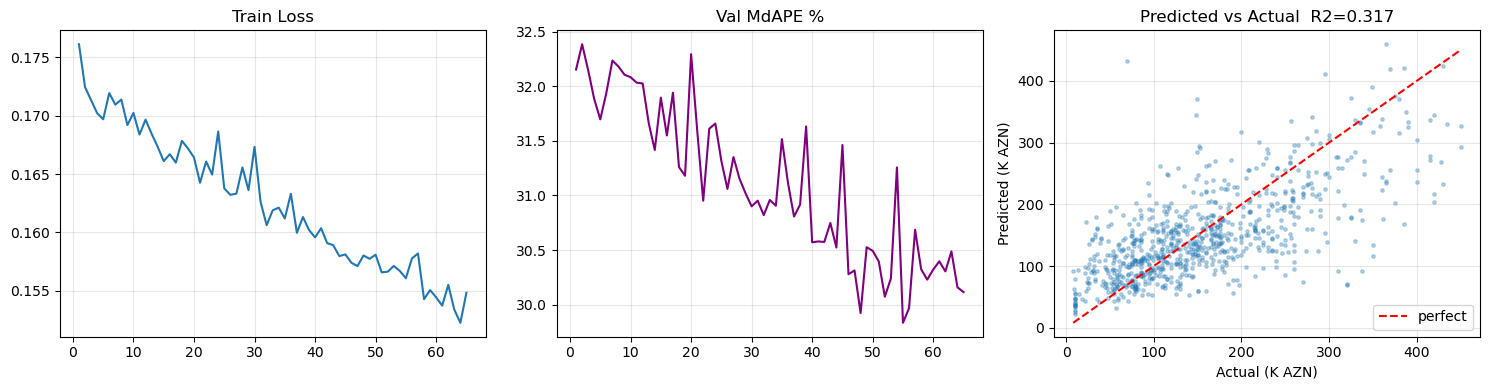

In [20]:
# 11. Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eps = range(1, len(history['loss']) + 1)

axes[0].plot(eps, history['loss'])
axes[0].set_title('Train Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['val_mdape'], color='purple')
axes[1].set_title('Val MdAPE %'); axes[1].grid(alpha=0.3)

cap  = np.percentile(te_targets, 95)
mask = te_targets < cap
axes[2].scatter(te_targets[mask]/1000, te_preds[mask]/1000, alpha=0.3, s=6)
mn, mx = te_targets[mask].min()/1000, te_targets[mask].max()/1000
axes[2].plot([mn, mx], [mn, mx], 'r--', label='perfect')
axes[2].set_title(f'Predicted vs Actual  R2={r2_score(te_targets, te_preds):.3f}')
axes[2].set_xlabel('Actual (K AZN)'); axes[2].set_ylabel('Predicted (K AZN)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results_v3.png', dpi=120)
plt.show()

## Step 13 - Workflow Cell 13
Persist generated outputs and artifacts for downstream use.

In [21]:
# 12. Save model
torch.save({
    'model_state': model.state_dict(),
    'y_mean':      Y_MEAN,
    'y_std':       Y_STD,
    'test_mdape':  mdape(te_targets, te_preds),
    'test_mae':    mean_absolute_error(te_targets, te_preds),
}, OUTPUT_DIR / 'house_price_v3.pt')
print('Model saved.')

Model saved.


## Step 14 - Workflow Cell 14
Run this notebook step and prepare outputs for the next stage.

In [22]:
# 13. Predict price for one house
def predict_price(folder_name):
    paths = get_image_paths(folder_name)
    if not paths:
        print('No images found.'); return

    # Get the embedding (re-use cached one if available, else compute now)
    hid = df[df['image_folder_name'] == folder_name]['house_id'].values
    if len(hid) > 0 and int(hid[0]) in embeddings:
        emb = embeddings[int(hid[0])]
    else:
        emb = embed_house(paths)  # compute on the fly for new houses

    model.eval()
    with torch.no_grad():
        pred = model(emb.unsqueeze(0).to(device)).squeeze()

    price  = float(np.expm1(np.clip(float(pred) * Y_STD + Y_MEAN, 6.0, 16.5)))
    margin = 1.28 * res_std

    print(f'Estimated: {price:,.0f} AZN')
    print(f'Range:     {max(0, price - margin):,.0f} – {price + margin:,.0f} AZN')


# Demo
demo = test_df.iloc[0]
print(f'Actual price: {demo.price:,.0f} AZN')
predict_price(str(demo['image_folder_name']))

Actual price: 57,120 AZN
Estimated: 194,998 AZN
Range:     0 – 398,854 AZN


## Step 15 - Workflow Cell 15
Run this notebook step and prepare outputs for the next stage.